In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stillib_plotting import use_style

from mscthesis.config import ProjectConfig
from mscthesis.core.io import load_dataframe
from mscthesis.paths import ProjectPaths

paths = ProjectPaths(ProjectConfig().behavior.storage_root)
df = load_dataframe(paths.collection.require())
print(len(df))

use_style()


def log3d_scatter(ax, x, y, z, *, base=10, logz=False, **scatter_kwargs):
    from matplotlib.ticker import FuncFormatter

    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    # mask = (x > 0) & (y > 0) & (z > 0)
    mask = np.ones_like(x, dtype=bool)

    if base == 10:
        (
            lx,
            ly,
            lz,
        ) = np.log10(x[mask]), np.log10(y[mask]), np.log10(z[mask])
        tick_label = lambda v: rf"$10^{{{int(v)}}}$"
    elif base == np.e:
        lx, ly, lz = np.log(x[mask]), np.log(y[mask]), np.log(z[mask])
        tick_label = lambda v: rf"$e^{{{int(v)}}}$"
    else:
        lx = np.log(x[mask]) / np.log(base)
        ly = np.log(y[mask]) / np.log(base)
        lz = np.log(z[mask]) / np.log(base)
        tick_label = lambda v: rf"${base}^{{{int(v)}}}$"

    if logz:
        sc = ax.scatter(lx, ly, lz, **scatter_kwargs)

        for axis, data in [
            (ax.xaxis, lx),
            (ax.yaxis, ly),
            (ax.zaxis, lz),
        ]:
            ticks = np.arange(np.floor(data.min()), np.ceil(data.max()) + 1)
            axis.axes.set_xticks(ticks) if axis is ax.xaxis else None

        ax.set_xticks(np.arange(np.floor(lx.min()), np.ceil(lx.max()) + 1))
        ax.set_yticks(np.arange(np.floor(ly.min()), np.ceil(ly.max()) + 1))
        ax.set_zticks(np.arange(np.floor(lz.min()), np.ceil(lz.max()) + 1))
    else:
        sc = ax.scatter(lx, ly, z[mask], **scatter_kwargs)

        for axis, data in [
            (ax.xaxis, lx),
            (ax.yaxis, ly),
            (ax.zaxis, z),
        ]:
            ticks = np.arange(np.floor(data.min()), np.ceil(data.max()) + 1)
            axis.axes.set_xticks(ticks) if axis is ax.xaxis else None

        ax.set_xticks(np.arange(np.floor(lx.min()), np.ceil(lx.max()) + 1))
        ax.set_yticks(np.arange(np.floor(ly.min()), np.ceil(ly.max()) + 1))
        ax.set_zticks(np.arange(np.floor(z.min()), np.ceil(z.max()) + 1))



    formatter = FuncFormatter(lambda val, pos: tick_label(val))
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    return sc





8505


0.9394452310344829 16.619736664345933 6.666666666666667 1.6372287706543889


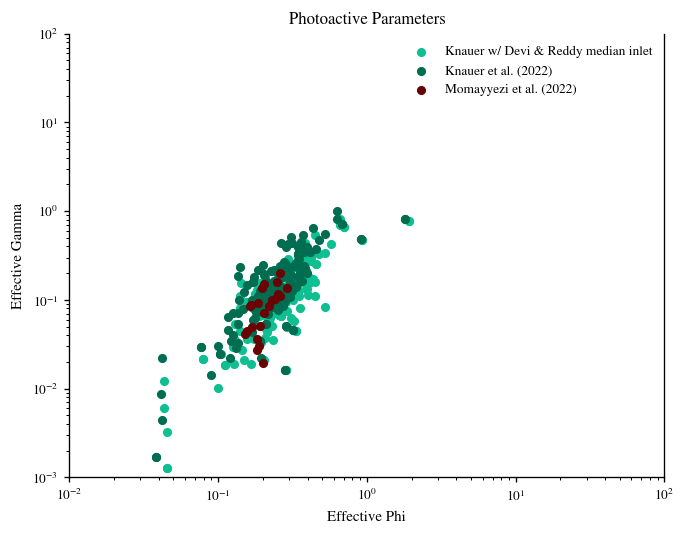

In [72]:
knauer = load_dataframe("../data/derived/Knauer_filtered.csv")
moma = load_dataframe("../data/derived/Momayyezi_filtered.csv")

diffusivity = 1.5e-5  # m2/s
tortuosity = 1.57

rias = 1e-6 * knauer["L"] * tortuosity / knauer["porosity"] / diffusivity / 2 * 0.02241

rcell = (knauer["Ci"] - knauer["Cistar"]) / knauer["An"] - rias

rstom = 1 / knauer["gs"]

knauer_phi_eff = np.sqrt(rias / rcell)
knauer_gamma_eff = rias / (rstom)# + rias)

estimated_rinlet = knauer["inlet_resistance"]
knauer_phi_eff_alternate = np.sqrt(rias/(rcell - estimated_rinlet))
knauer_gamma_eff_alternate = rias / (rstom + estimated_rinlet)

print(np.median(rias), np.median(rcell), np.median(rstom), np.median(estimated_rinlet))



rias = 1/moma["gias"]
rcell = (moma["Ci"] - moma["Cistar"]) / moma["An"] - rias
rstom = 1 / moma["gs"]

moma_phi_eff = np.sqrt(rias / rcell)
moma_gamma_eff = rias / (rstom)# + rias)

plt.scatter(knauer_phi_eff_alternate, knauer_gamma_eff_alternate, s=20, color="#0EC091", label="Knauer w/ Devi & Reddy median inlet")
plt.scatter(knauer_phi_eff, knauer_gamma_eff, s=20, color="#016D50", label="Knauer et al. (2022)")
plt.scatter(moma_phi_eff, moma_gamma_eff, s=20, color="#6A0303", label="Momayyezi et al. (2022)")
plt.xlabel("Effective Phi")
plt.ylabel("Effective Gamma")
plt.title("Photoactive Parameters")
plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-2, 1e2)
plt.ylim(1e-3, 1e2)
plt.legend()
plt.show()


Effective $\phi'$ is a lower bound and effective $\gamma'$ is an upper bound. So reality is pushed down towards the lower right corner. Assuming a median $r_{inlet}$ as estimated from Devi & Reddy et al. 2018 we dont get that big of a correction. $r_s$ is on the order of 7, so $r_{inlet}$ would have to be comparable for it to have an impact $\rightarrow$ with a standard stomatal aspect of 0.02, the plug aspect would have to be larger than 0.4 which implies stomatal density less than 1.99e6 / $L^2$. For a typical mesophyll thickness of 172 µm this means $d < 67 mm^{-2}$ where the mean is $189 mm^{-2}$ according to Liu et al. 2018., with a recorded minimum of $9 mm^{-2}$ 

### Variation over mesophyll cell surfaces

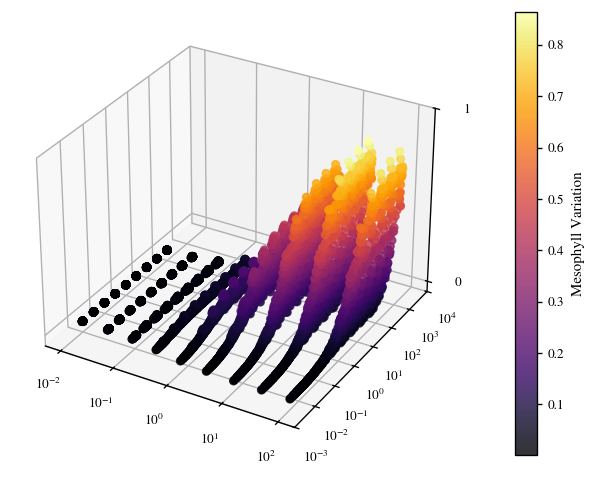

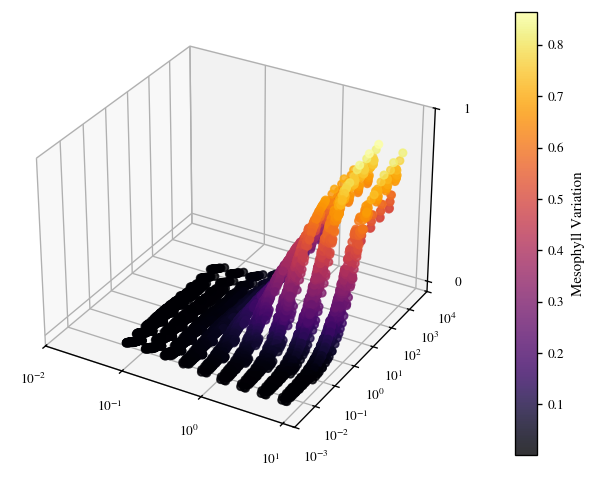

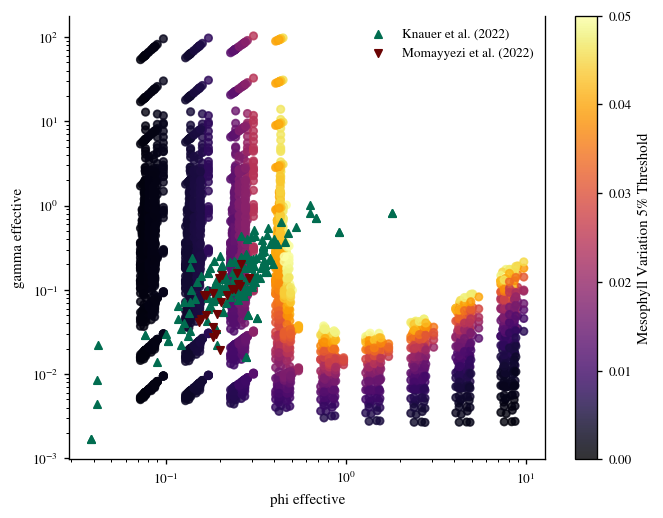

In [66]:
# Plot coefficient of variation over cell surfaces first in (phi, gamma), then in (phi', gamma')

phi_eff = np.sqrt(df["diffusive_pipe_resistance_m"] * df["absorption"]) # how does cell-domain diffusion compare to absorption?
gamma_eff = df["diffusive_pipe_resistance_m"] / (df["diffusive_resistance_m"] - df["diffusive_pipe_resistance_m"] + 1/df["transport"]) # what fraction of the total resistance is due to the cell domain?

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    df["absorption"],
    df["transport"],
    df["mesophyll_variation"],
    c=df["mesophyll_variation"],
    logz=False,
    cmap="inferno",
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Mesophyll Variation")
plt.show()


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    phi_eff,
    gamma_eff,
    df["mesophyll_variation"],
    c=df["mesophyll_variation"],
    logz=False,
    cmap="inferno",
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Mesophyll Variation")
plt.show()


# filter for points with variation less than threshold
threshold = 0.05
mask = df["mesophyll_variation"] < threshold
# plot 2D projection of these points in (phi, gamma) space
fig = plt.figure()
ax = fig.add_subplot(111)
sc = ax.scatter(
    phi_eff[mask],
    gamma_eff[mask],
    c=df[mask]["mesophyll_variation"],
    cmap="inferno",
    s=20,
    alpha=0.8,
    vmin=0,
    vmax=threshold,
)
plt.scatter(knauer_phi_eff, knauer_gamma_eff, s=20, marker="^", color="#016D50", label="Knauer et al. (2022)")
plt.scatter(moma_phi_eff, moma_gamma_eff, s=20, marker="v", color="#6A0303", label="Momayyezi et al. (2022)")
ax.legend()
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Mesophyll Variation 5% Threshold")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("phi effective")
ax.set_ylabel("gamma effective")
plt.show()


### Does Photoactivity affect only pipe contribution? And does total resistance approach diffusive estimate for $\phi \rightarrow 0$?

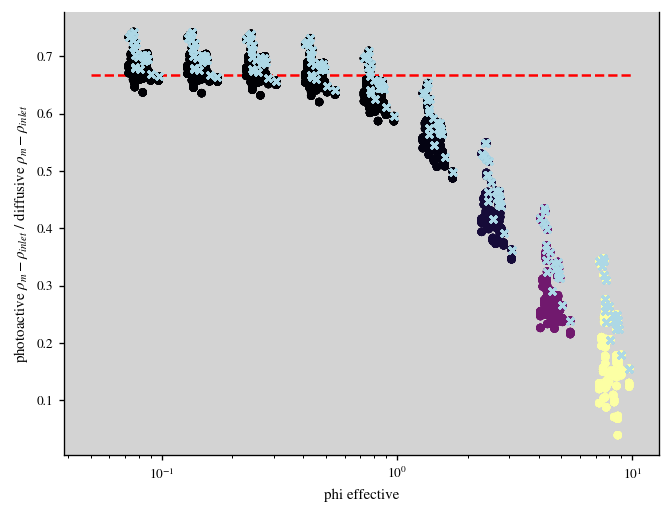

In [109]:
# correlate resistance_m with diffusive_resistance_m 

plt.scatter(phi_eff, (df["resistance_m"] - df["diffusive_inlet_resistance"]) / (df["diffusive_resistance_m"] - df["diffusive_inlet_resistance"]), c=df["absorption"], cmap="inferno", marker="o", zorder=3)

mask = df["specifier"] == 0 
plt.scatter(phi_eff[mask], (df[mask]["resistance_m"] - df[mask]["diffusive_inlet_resistance"]) / (df[mask]["diffusive_resistance_m"] - df[mask]["diffusive_inlet_resistance"]), color="lightblue", marker="x", zorder=3)
# set background as light gray
plt.gca().set_facecolor("lightgray")

phi_eff_ = np.logspace(-1.3, 1, 100)
# plt.plot(phi_eff_, (1 - np.tanh(np.sqrt(phi_eff_)/np.sqrt(phi_eff_))/(np.sqrt(phi_eff_)*np.tanh(np.sqrt(phi_eff_)))))
plt.plot(phi_eff_, 2/3 * np.ones_like(phi_eff_), color="red", linestyle="--", label="Theoretical Limit")

plt.xscale("log")
plt.xlabel("phi effective")
plt.ylabel(r"photoactive $\rho_m - \rho_{inlet}$ / diffusive $\rho_m - \rho_{inlet}$")
plt.show()

We see that there is a discontinuity when cells are photoactive, even as $\phi \rightarrow 0$, that is: the resistance is reduced roughly by a factor 0.7 and more as $\phi$ increases. In that limit, the mutation is also no longer local to the pipe contribution but depends on the inlet component as well.

### Using diffusive estimates, what are the associated errors in mean conc. and assimilaton rate? ($\delta U = 0$ case)

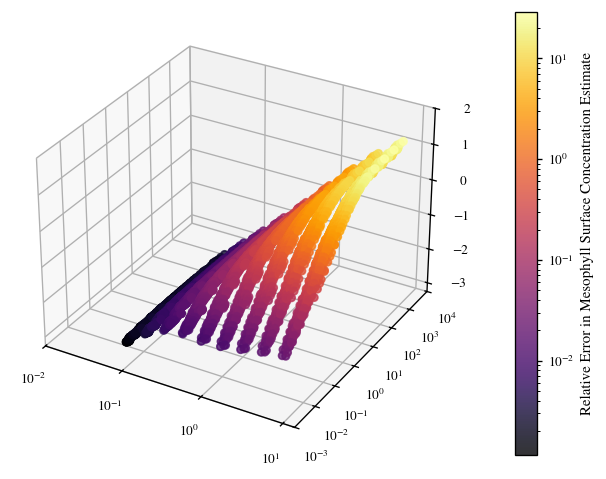

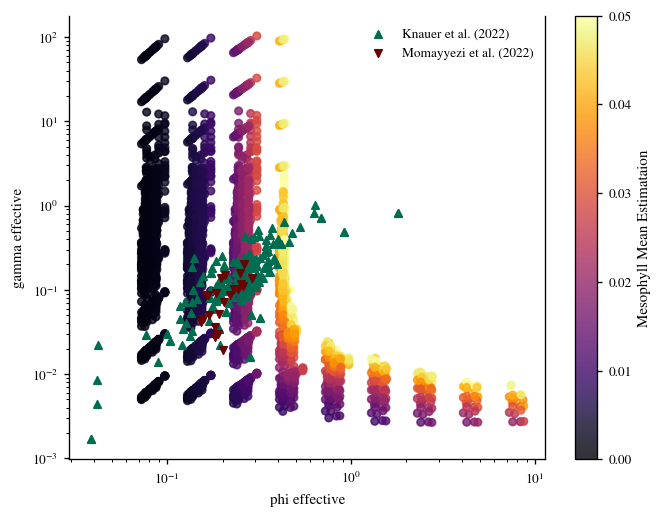

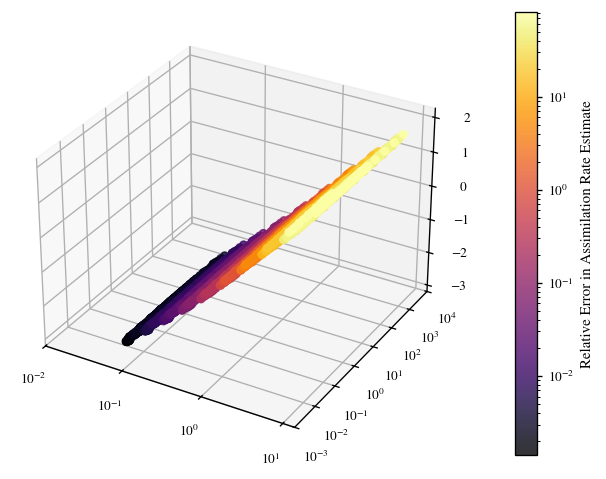

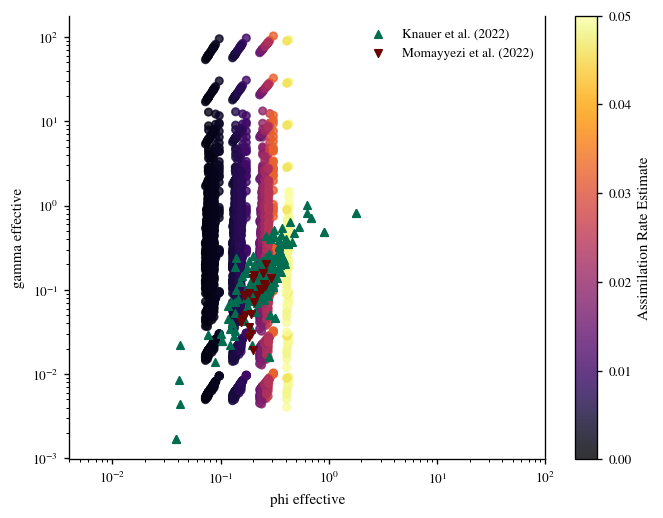

In [68]:
chim = df["mesophyll_mean"]
chim_diffusion = df["substomatal_mean"] - df["diffusive_resistance_m"] * df["assimilation_rate"] 

rel_err = (chim - chim_diffusion) / chim

# make a log distributed colormap 
from matplotlib.colors import LogNorm
cmap = plt.get_cmap("inferno")
norm = LogNorm(vmin=rel_err.min(), vmax=rel_err.max())

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    phi_eff,
    gamma_eff,
    rel_err,
    c=rel_err,
    logz=True,
    cmap="inferno",
    norm=norm,
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Relative Error in Mesophyll Surface Concentration Estimate")
plt.show()


threshold = 0.05
mask = rel_err < threshold
# plot 2D projection of these points in (phi, gamma) space
fig = plt.figure()
ax = fig.add_subplot(111)
sc = ax.scatter(
    phi_eff[mask],
    gamma_eff[mask],
    c=rel_err[mask],
    cmap="inferno",
    s=20,
    alpha=0.8,
    vmin=0,
    vmax=threshold,
)
plt.scatter(knauer_phi_eff, knauer_gamma_eff, s=20, marker="^", color="#016D50", label="Knauer et al. (2022)")
plt.scatter(moma_phi_eff, moma_gamma_eff, s=20, marker="v", color="#6A0303", label="Momayyezi et al. (2022)")
ax.legend()
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Mesophyll Mean Estimataion")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("phi effective")
ax.set_ylabel("gamma effective")
plt.show()




# ============================================


assim_diffusion = df["absorption"] * (chim_diffusion - df["compensation"])
rel_err= np.abs(df["assimilation_rate"] - assim_diffusion) / df["assimilation_rate"]


norm = LogNorm(vmin=rel_err.min(), vmax=rel_err.max())

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    phi_eff,
    gamma_eff,
    rel_err,
    c=rel_err,
    logz=True,
    cmap="inferno",
    norm=norm,
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Relative Error in Assimilation Rate Estimate")
plt.show()

threshold = 0.05
mask = rel_err < threshold
# plot 2D projection of these points in (phi, gamma) space
fig = plt.figure()
ax = fig.add_subplot(111)
sc = ax.scatter(
    phi_eff[mask],
    gamma_eff[mask],
    c=rel_err[mask],
    cmap="inferno",
    s=20,
    alpha=0.8,
    vmin=0,
    vmax=threshold,
)
plt.scatter(knauer_phi_eff, knauer_gamma_eff, s=20, marker="^", color="#016D50", label="Knauer et al. (2022)")
plt.scatter(moma_phi_eff, moma_gamma_eff, s=20, marker="v", color="#6A0303", label="Momayyezi et al. (2022)")
ax.legend()
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Assimilation Rate Estimate")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("phi effective")
ax.set_ylabel("gamma effective")
ax.set_xlim(4e-3, 1e2)
plt.show()


### Phase plots of usual quantities

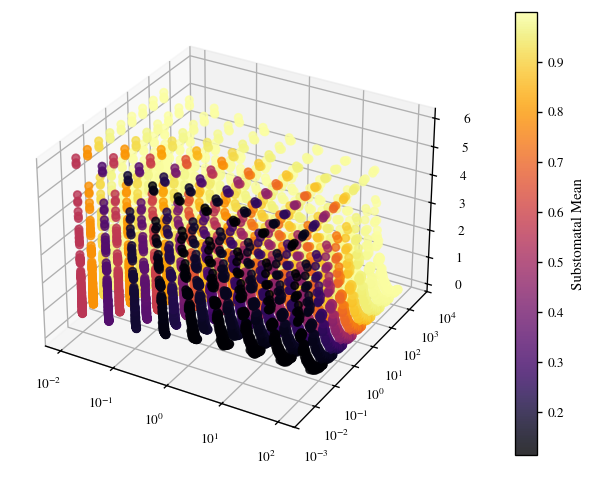

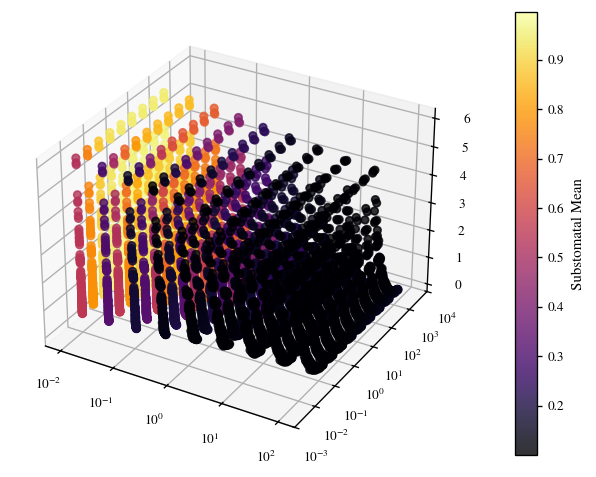

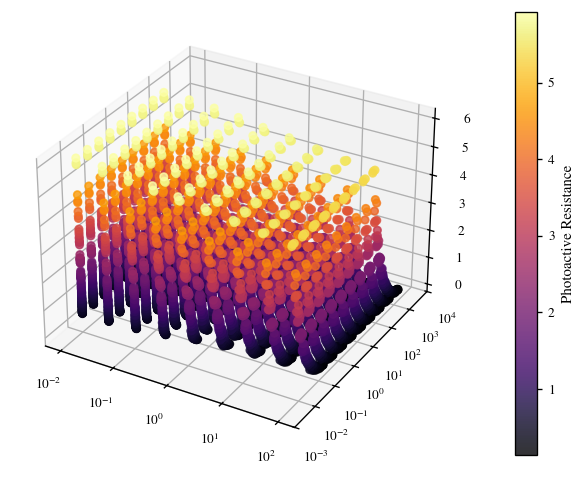

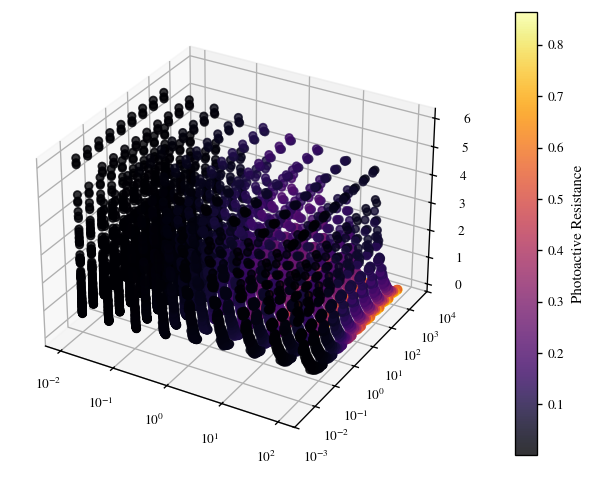

In [69]:
values = df["substomatal_mean"]


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    df["absorption"],
    df["transport"],
    df["resistance_m"],
    c=values,
    cmap="inferno",
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Substomatal Mean")
plt.show()

values = df["mesophyll_mean"]


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    df["absorption"],
    df["transport"],
    df["resistance_m"],
    c=values,
    cmap="inferno",
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Substomatal Mean")
plt.show()

values = df["resistance_m"]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    df["absorption"],
    df["transport"],
    df["resistance_m"],
    c=values,
    cmap="inferno",
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Photoactive Resistance")
plt.show()


values = df["mesophyll_variation"]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    df["absorption"],
    df["transport"],
    df["resistance_m"],
    c=values,
    cmap="inferno",
    s=20,
    alpha=0.8,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Photoactive Resistance")
plt.show()

(0.0, 1.0)

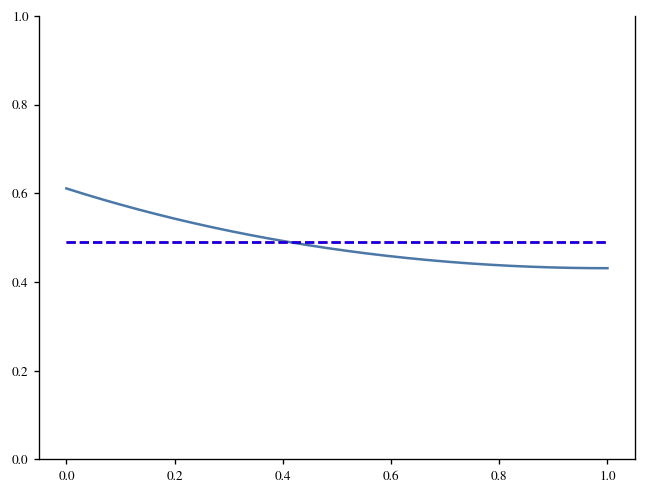

In [70]:
x = np.linspace(0, 1, 500)

def chi(x, tau, gamma, chi_):
    return chi_ + (1 - chi_) / (1 + tau/gamma * np.tanh(tau)) * np.cosh(tau * (1 - x)) / np.cosh(tau)

def chi_mean(tau, gamma, chi_):
    return chi_ + (1 - chi_) * (np.tanh(tau) / tau) / (1 + tau/gamma * np.tanh(tau))

y = chi(x, 1.0, 1.0, 0.1)


plt.plot(x, y)
plt.plot(x, chi_mean(1.0, 1.0, 0.1) * np.ones_like(x), "--", color="red")
plt.plot(x, np.mean(y) * np.ones_like(x), "--", color="blue")
plt.ylim(0,1)

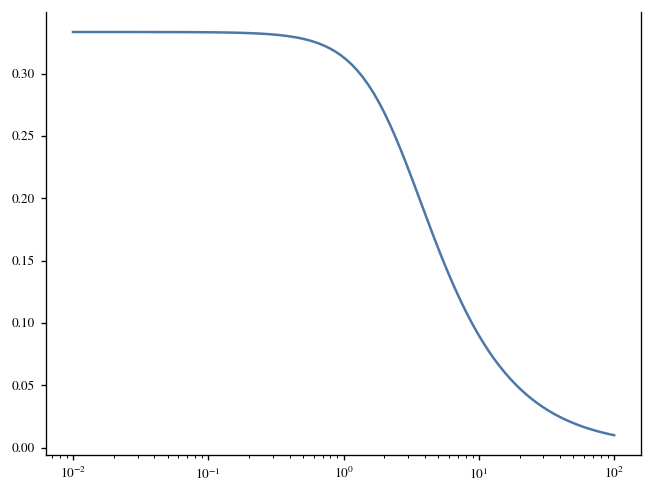

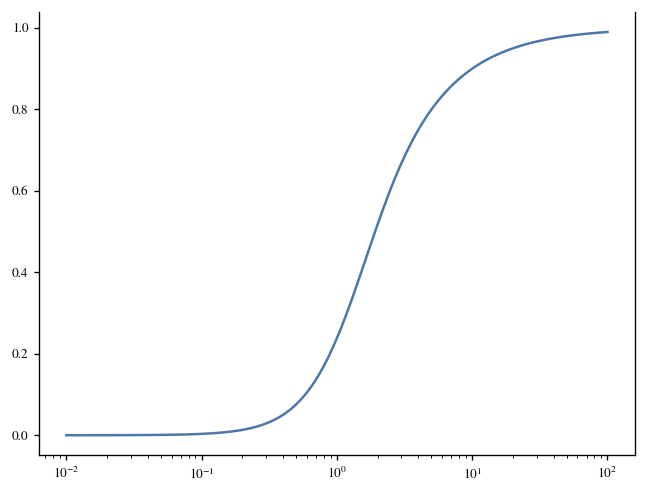

In [71]:
taus = np.logspace(-2, 2, 100)
gamma = 0.001

y = (1/gamma + 1/taus/np.tanh(taus)) * (1 - np.tanh(taus) / taus) / (1 + taus * np.tanh(taus) / gamma)
plt.plot(taus, y)
plt.xscale("log")
plt.show()

plt.plot(taus, 1 - np.tanh(taus)/taus)
plt.xscale("log")